# **House Price Prediction - PreProcessing Data**

## **Persiapan LIBRARY**

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

## **IMPORT DATASET**

In [102]:
# Load dataset
df = pd.read_csv("/content/train.csv")

print("Dataset berhasil dimuat")

Dataset berhasil dimuat


## **EKSPLORASI ANALISIS DATA**

### Dimensi data dan Informasi dasar

In [103]:
# Cek dimensi
print("--- Dimensi Dataset ---")
print(f"Bentuk data Train: {df.shape} (baris, kolom)")
print()

# Tipe data
print("--- Ringkasan Tipe Data pada Train ---")
print(df.dtypes.value_counts())
print()

# Baris pertama
print("--- 5 Baris Pertama Data Train ---")
df.head()

--- Dimensi Dataset ---
Bentuk data Train: (1460, 81) (baris, kolom)

--- Ringkasan Tipe Data pada Train ---
object     43
int64      35
float64     3
Name: count, dtype: int64

--- 5 Baris Pertama Data Train ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Terlihat 38 Fitur bernilai numerik dn beberapa memiliki nilai NaN

In [104]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## Info Dataset

| No. | Kelompok | Kolom |
|---:|---|---|
| 1 | Identifier | `Id` |
| 2 | Target | `SalePrice` |
| 3 | Informasi Properti | `MSSubClass`, `MSZoning`, `BldgType`, `HouseStyle` |
| 4 | Karakteristik Lahan | `LotFrontage`, `LotArea`, `Street`, `Alley`, `LotShape`, `LandContour`, `Utilities`, `LotConfig`, `LandSlope` |
| 5 | Lokasi & Kondisi Sekitar | `Neighborhood`, `Condition1`, `Condition2` |
| 6 | Kualitas & Kondisi Rumah | `OverallQual`, `OverallCond` |
| 7 | Tahun & Renovasi | `YearBuilt`, `YearRemodAdd` |
| 8 | Atap | `RoofStyle`, `RoofMatl` |
| 9 | Eksterior | `Exterior1st`, `Exterior2nd`, `MasVnrType`, `MasVnrArea`, `ExterQual`, `ExterCond` |
| 10 | Pondasi & Basement | `Foundation`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinSF1`, `BsmtFinType2`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF`, `BsmtFullBath`, `BsmtHalfBath` |
| 11 | Sistem Rumah | `Heating`, `HeatingQC`, `CentralAir`, `Electrical` |
| 12 | Luas Bangunan | `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`, `GrLivArea` |
| 13 | Kamar & Ruangan | `FullBath`, `HalfBath`, `BedroomAbvGr`, `KitchenAbvGr`, `KitchenQual`, `TotRmsAbvGrd` |
| 14 | Fungsi Rumah | `Functional` |
| 15 | Fireplace | `Fireplaces`, `FireplaceQu` |
| 16 | Garage | `GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageCars`, `GarageArea`, `GarageQual`, `GarageCond` |
| 17 | Driveway | `PavedDrive` |
| 18 | Outdoor Area | `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`, `3SsnPorch`, `ScreenPorch` |
| 19 | Pool | `PoolArea`, `PoolQC` |
| 20 | Fitur Tambahan | `Fence`, `MiscFeature`, `MiscVal` |
| 21 | Informasi Penjualan | `MoSold`, `YrSold`, `SaleType`, `SaleCondition` |


### Duplikasi & Cek bahwa semua ID adalah UNIK

In [105]:
# Cek duplikasi
df_dups_count = df.duplicated().sum()

print("--- Pemeriksaan Duplikasi Baris ---")
print(f"Baris duplikat di Train: {df_dups_count}")
print()

# Cek uniqueness ID
print("--- Keunikan Kolom Id ---")
print(f"Id unik di Train: {df['Id'].nunique()} dari {len(df)} baris")

--- Pemeriksaan Duplikasi Baris ---
Baris duplikat di Train: 0

--- Keunikan Kolom Id ---
Id unik di Train: 1460 dari 1460 baris


Telah dipastikan tidak ada data duplikat

### Overview Nilai Missing

In [106]:
# Fungsi untuk cek missing values
def check_missing(df, name="Dataset"):
    missing_count = df.isnull().sum()
    missing_pct = (missing_count / len(df)) * 100
    missing_df = pd.DataFrame({
        "Jumlah Missing": missing_count,
        "Persentase (%)": missing_pct
    })
    missing_df = missing_df[missing_df["Jumlah Missing"] > 0].sort_values(
        by="Persentase (%)", ascending=False
    )
    print(f"=== Missing Values pada {name} ({len(missing_df)} kolom) ===")
    return missing_df

missing_train = check_missing(df, "Train")
print(missing_train)
print()

=== Missing Values pada Train (19 kolom) ===
              Jumlah Missing  Persentase (%)
PoolQC                  1453       99.520548
MiscFeature             1406       96.301370
Alley                   1369       93.767123
Fence                   1179       80.753425
MasVnrType               872       59.726027
FireplaceQu              690       47.260274
LotFrontage              259       17.739726
GarageType                81        5.547945
GarageYrBlt               81        5.547945
GarageFinish              81        5.547945
GarageQual                81        5.547945
GarageCond                81        5.547945
BsmtExposure              38        2.602740
BsmtFinType2              38        2.602740
BsmtQual                  37        2.534247
BsmtCond                  37        2.534247
BsmtFinType1              37        2.534247
MasVnrArea                 8        0.547945
Electrical                 1        0.068493



Fitur `PoolQC`,`MiscFeature`,`Alley`, `Fence`, `MasVnrType` memiliki missing value >=50%. Kita diperintahkan untuk menghapus kolom tersebut

### Hapus fitur dengan missing value >=50%

In [107]:
cols= ['PoolQC','MiscFeature','Alley','Fence','MasVnrType']
df_nonan = df.drop(columns=cols)
print(f"Train shape setelah drop kolom: {df_nonan.shape}")

Train shape setelah drop kolom: (1460, 76)


### Target Variable Distribution

=== Statistik Deskriptif SalePrice ===
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness SalePrice: 1.8829


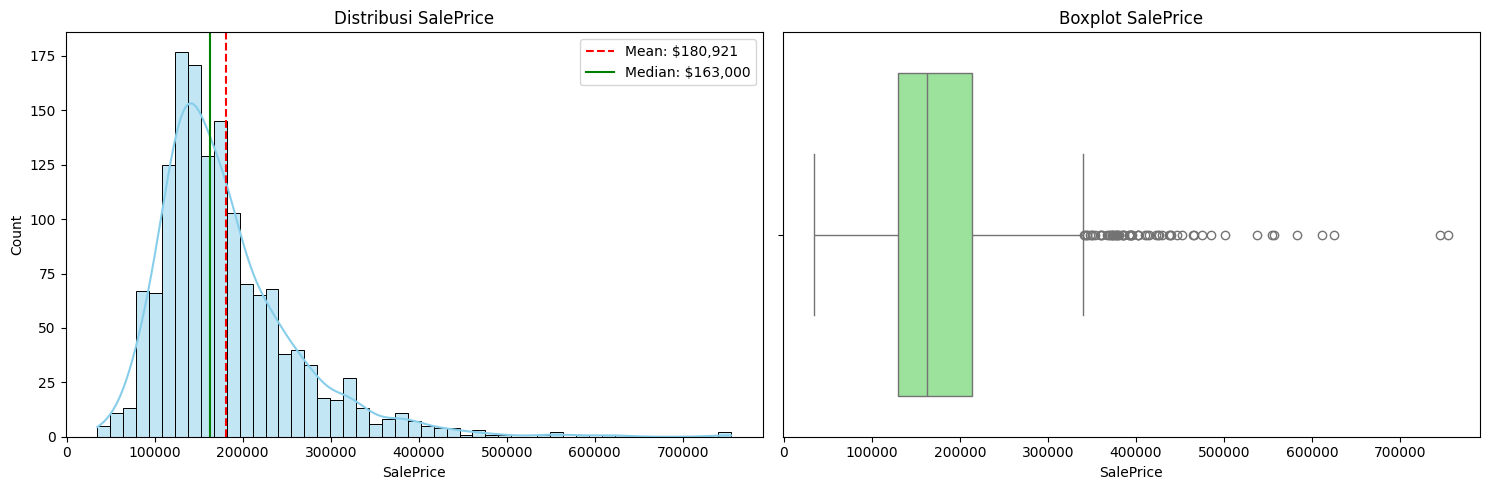

In [108]:
# Statistik SalePrice
mean_sp = df_nonan["SalePrice"].mean()
median_sp = df_nonan["SalePrice"].median()
skew_sp = df_nonan["SalePrice"].skew()

print("=== Statistik Deskriptif SalePrice ===")
print(df_nonan["SalePrice"].describe())
print(f"\nSkewness SalePrice: {skew_sp:.4f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram + KDE
sns.histplot(df["SalePrice"], kde=True, ax=axes[0], color="skyblue")
axes[0].axvline(mean_sp, color="red", linestyle="--", label=f"Mean: ${mean_sp:,.0f}")
axes[0].axvline(median_sp, color="green", linestyle="-", label=f"Median: ${median_sp:,.0f}")
axes[0].set_title("Distribusi SalePrice")
axes[0].legend()

# Boxplot
sns.boxplot(x=df["SalePrice"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot SalePrice")

plt.tight_layout()
plt.show()

Terdapat banyak outlier pada Atribut SalePrice

### Feature Importance & Correlation

=== Top 10 Fitur Numerik Berpengaruh ===
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


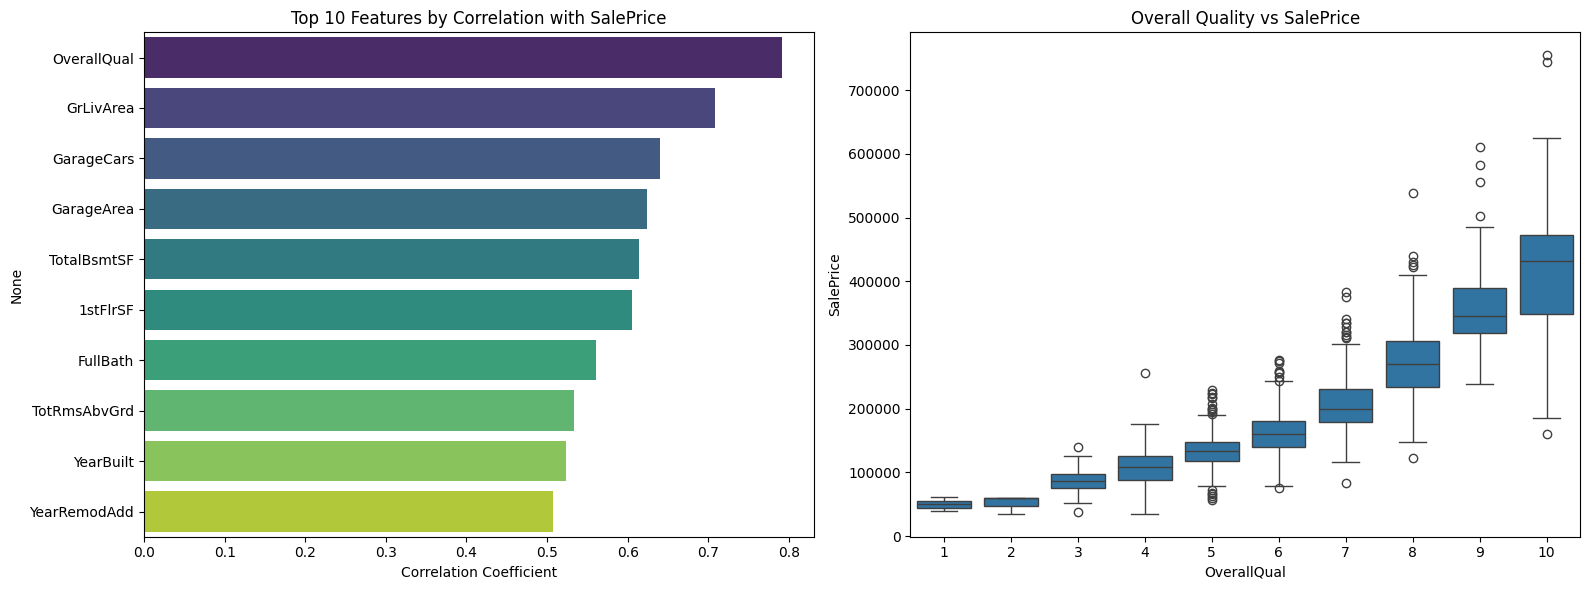

In [109]:
# Fitur top dengan analisis korelasi
num_cols =df_nonan.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [col for col in num_cols if col not in ["Id", "MSSubClass"]]

correlations = df_nonan[num_cols].corr()["SalePrice"].sort_values(ascending=False)

print("=== Top 10 Fitur Numerik Berpengaruh ===")
print(correlations.head(11))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot top 10
top_10 = correlations[1:11]
sns.barplot(x=top_10.values, y=top_10.index, palette="viridis", ax=axes[0])
axes[0].set_title("Top 10 Features by Correlation with SalePrice")
axes[0].set_xlabel("Correlation Coefficient")

# OverallQual vs SalePrice
sns.boxplot(x="OverallQual", y="SalePrice", data=df_nonan, ax=axes[1])
axes[1].set_title("Overall Quality vs SalePrice")

plt.tight_layout()
plt.show()

Nampak ada outlier yang banyak pada fitur 5-8

### Numerical Features Skewness

In [110]:
# Hitung skewness semua fitur numerik
num_cols_all = df_nonan.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols_analysis = [col for col in num_cols_all if col not in ["Id", "SalePrice"]]

skewness_df = pd.DataFrame({
    "Feature": num_cols_analysis,
    "Skewness": [df_nonan[col].skew() for col in num_cols_analysis],
    "Missing_Count": [df_nonan[col].isnull().sum() for col in num_cols_analysis]
})

# Kategorisasi skewness
def categorize_skewness(value):
    if abs(value) > 1.0:
        return "Sangat Miring"
    elif 0.5 <= abs(value) <= 1.0:
        return "Agak Miring"
    else:
        return "Simetris"

skewness_df["Kategori"] = skewness_df["Skewness"].apply(categorize_skewness)

# Urutkan berdasarkan nilai skewness
skewness_df = (
    skewness_df
    .sort_values(by="Skewness", ascending=False)
    .reset_index(drop=True)
)

# ==============================
# REKAPITULASI
# ==============================

sangat_miring = skewness_df[skewness_df["Kategori"] == "Sangat Miring"]
agak_miring = skewness_df[skewness_df["Kategori"] == "Agak Miring"]
simetris = skewness_df[skewness_df["Kategori"] == "Simetris"]

print("=== Rekapitulasi Skewness Fitur Numerik ===")
print(f"Total fitur numerik yang dianalisis : {len(skewness_df)}")
print(f"Fitur Sangat Miring (|Skew| > 1.0) : {len(sangat_miring)}")
print(f"Fitur Agak Miring (0.5 <= |Skew| <= 1.0) : {len(agak_miring)}")
print(f"Fitur Simetris (|Skew| < 0.5) : {len(simetris)}")


# ==============================
# NAMA FITUR PER KATEGORI
# ==============================

print("\n=== FITUR SANGAT MIRING ===")
for _, row in sangat_miring.iterrows():
    print(f"- {row['Feature']}: Skewness = {row['Skewness']:.3f}")

print("\n=== FITUR AGAK MIRING ===")
for _, row in agak_miring.iterrows():
    print(f"- {row['Feature']}: Skewness = {row['Skewness']:.3f}")

print("\n=== FITUR SIMETRIS / TIDAK SKEWED ===")
for _, row in simetris.iterrows():
    print(f"- {row['Feature']}: Skewness = {row['Skewness']:.3f}")


# ==============================
# TABEL LENGKAP
# ==============================

print("\n=== Tabel Skewness Lengkap ===")
display(skewness_df)

=== Rekapitulasi Skewness Fitur Numerik ===
Total fitur numerik yang dianalisis : 36
Fitur Sangat Miring (|Skew| > 1.0) : 19
Fitur Agak Miring (0.5 <= |Skew| <= 1.0) : 10
Fitur Simetris (|Skew| < 0.5) : 7

=== FITUR SANGAT MIRING ===
- MiscVal: Skewness = 24.477
- PoolArea: Skewness = 14.828
- LotArea: Skewness = 12.208
- 3SsnPorch: Skewness = 10.304
- LowQualFinSF: Skewness = 9.011
- KitchenAbvGr: Skewness = 4.488
- BsmtFinSF2: Skewness = 4.255
- ScreenPorch: Skewness = 4.122
- BsmtHalfBath: Skewness = 4.103
- EnclosedPorch: Skewness = 3.090
- MasVnrArea: Skewness = 2.669
- OpenPorchSF: Skewness = 2.364
- LotFrontage: Skewness = 2.164
- BsmtFinSF1: Skewness = 1.686
- WoodDeckSF: Skewness = 1.541
- TotalBsmtSF: Skewness = 1.524
- MSSubClass: Skewness = 1.408
- 1stFlrSF: Skewness = 1.377
- GrLivArea: Skewness = 1.367

=== FITUR AGAK MIRING ===
- BsmtUnfSF: Skewness = 0.920
- 2ndFlrSF: Skewness = 0.813
- OverallCond: Skewness = 0.693
- TotRmsAbvGrd: Skewness = 0.676
- HalfBath: Skewness 

,Feature,Skewness,Missing_Count,Kategori
0,MiscVal,24.476794,0,Sangat Miring
1,PoolArea,14.828374,0,Sangat Miring
2,LotArea,12.207688,0,Sangat Miring
3,3SsnPorch,10.304342,0,Sangat Miring
4,LowQualFinSF,9.011341,0,Sangat Miring
5,KitchenAbvGr,4.488397,0,Sangat Miring
6,BsmtFinSF2,4.255261,0,Sangat Miring
7,ScreenPorch,4.122214,0,Sangat Miring
8,BsmtHalfBath,4.103403,0,Sangat Miring
9,EnclosedPorch,3.089872,0,Sangat Miring


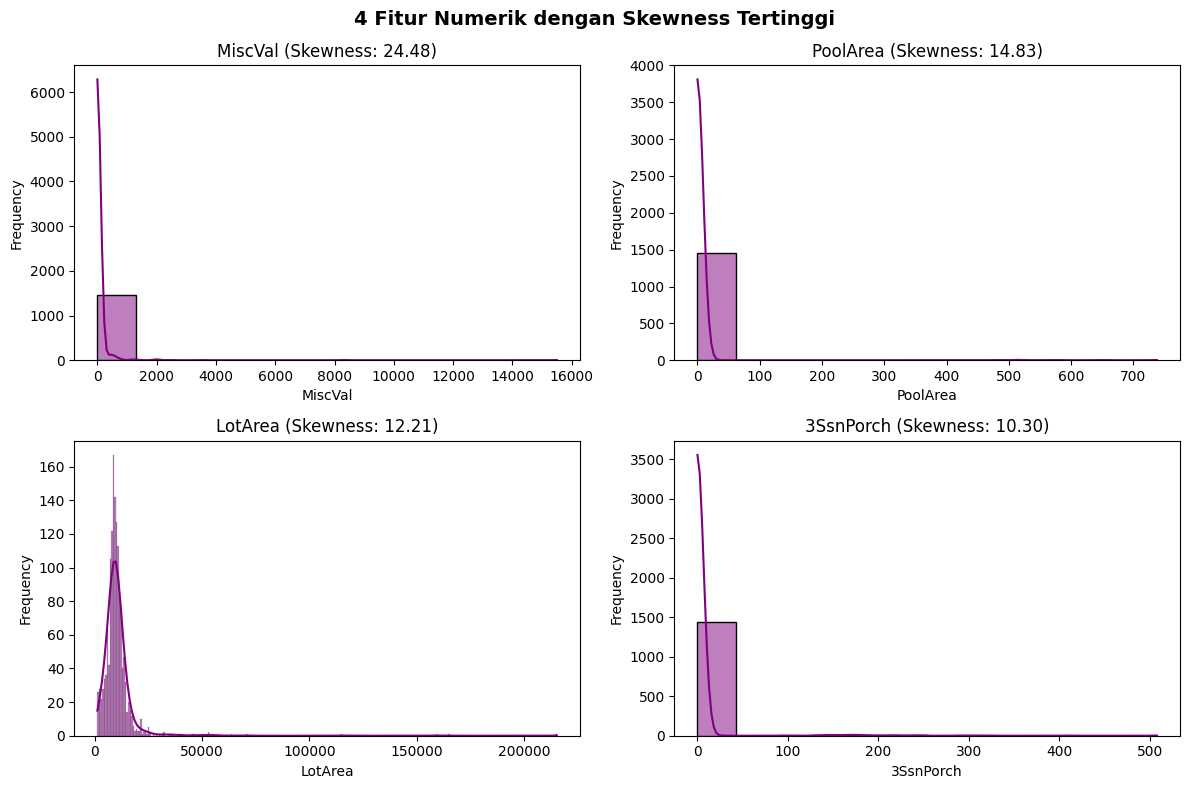

In [111]:
# VISUALISASI 4 FITUR PALING SKEWED
# ==============================

# Ambil 4 fitur dengan |skewness| terbesar
top_4_skewed = (
    skewness_df
    .assign(Abs_Skewness=skewness_df["Skewness"].abs())
    .sort_values(by="Abs_Skewness", ascending=False)
    .head(4)["Feature"]
    .tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(top_4_skewed):
    sns.histplot(df_nonan[col], kde=True, ax=axes[i], color="purple")
    axes[i].set_title(
        f"{col} (Skewness: {df_nonan[col].skew():.2f})"
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "4 Fitur Numerik dengan Skewness Tertinggi",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Neighborhood Analysis

=== 5 Lokasi Termahal ===
              count    median           mean
Neighborhood                                
NridgHt          77  315000.0  316270.623377
NoRidge          41  301500.0  335295.317073
StoneBr          25  278000.0  310499.000000
Timber           38  228475.0  242247.447368
Somerst          86  225500.0  225379.837209

=== 5 Lokasi Termurah ===
              count    median           mean
Neighborhood                                
Edwards         100  121750.0  128219.700000
OldTown         113  119000.0  128225.300885
BrDale           16  106000.0  104493.750000
IDOTRR           37  103000.0  100123.783784
MeadowV          17   88000.0   98576.470588


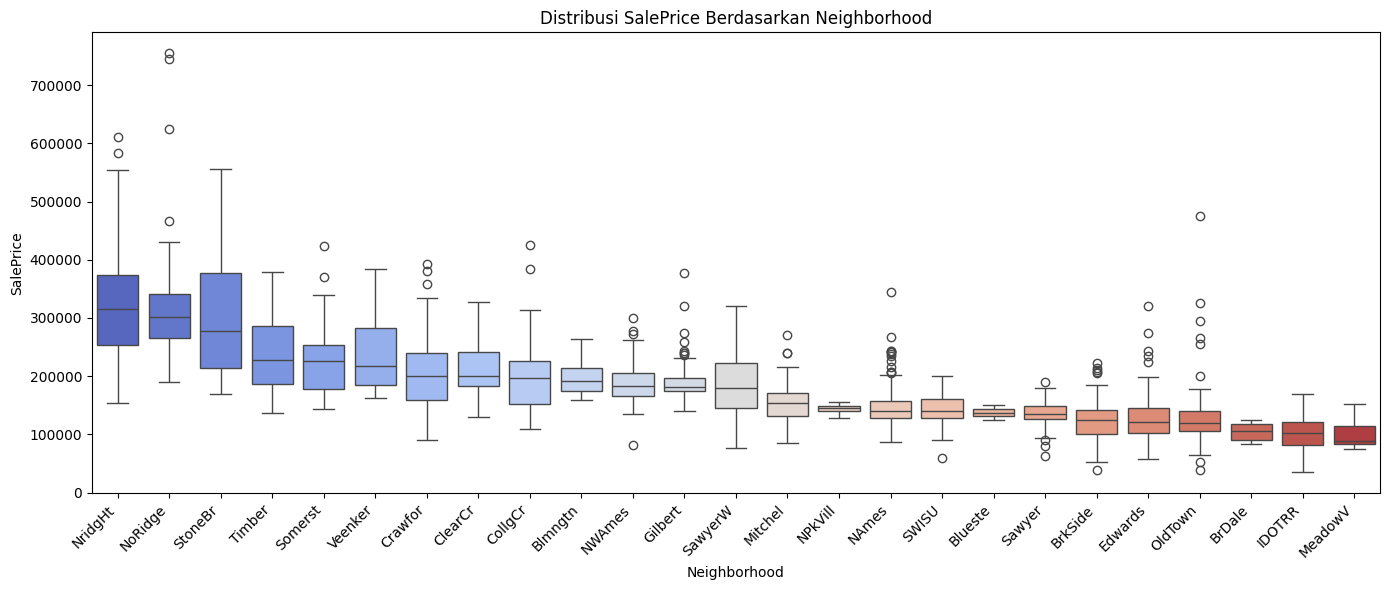

In [112]:
# Neighborhood price analysis
neighborhood_order = df_nonan.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).index
neighborhood_stats = df_nonan.groupby("Neighborhood")["SalePrice"].agg(["count", "median", "mean"]).sort_values(by="median", ascending=False)

print("=== 5 Lokasi Termahal ===")
print(neighborhood_stats.head(5))
print("\n=== 5 Lokasi Termurah ===")
print(neighborhood_stats.tail(5))

# Visualisasi
plt.figure(figsize=(14, 6))
sns.boxplot(x="Neighborhood", y="SalePrice", data=df_nonan, order=neighborhood_order, palette="coolwarm")
plt.xticks(rotation=45, ha="right")
plt.title("Distribusi SalePrice Berdasarkan Neighborhood")
plt.tight_layout()
plt.show()

## **4. DATA CLEANING**

## **Deteksi & Penghapusan Outlier GrLivArea**

### Threshold 4000 Sqft

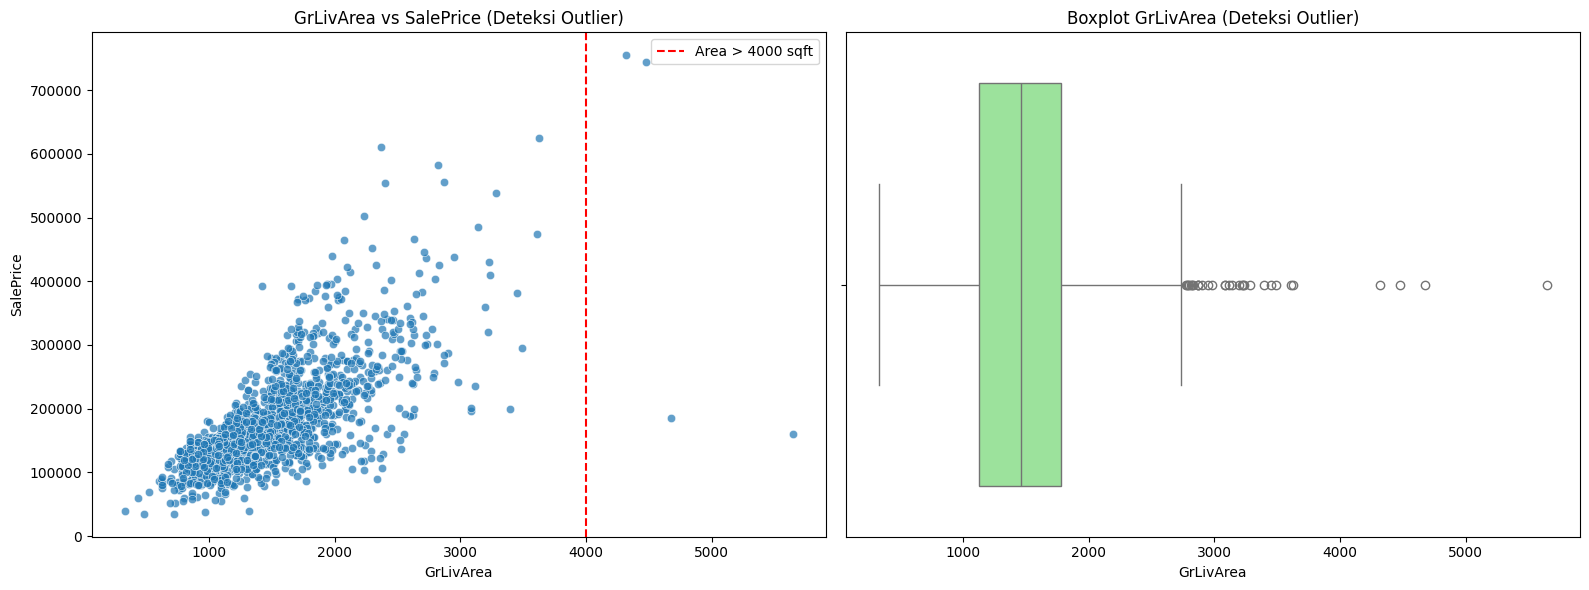

In [113]:
# Identifikasi outlier ekstrem di GrLivArea
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x="GrLivArea", y="SalePrice", data=df_nonan, ax=axes[0], alpha=0.7)
axes[0].set_title("GrLivArea vs SalePrice (Deteksi Outlier)")
axes[0].axvline(x=4000, color="red", linestyle="--", label="Area > 4000 sqft")
axes[0].legend()

sns.boxplot(x=df_nonan["GrLivArea"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot GrLivArea (Deteksi Outlier)")

plt.tight_layout()
plt.show()

In [114]:
# Tampilkan outlier ekstrem
outlier_candidates = df_nonan[df_nonan["GrLivArea"] > 4000][["Id", "OverallQual", "GrLivArea", "SalePrice"]]
print("=== Rumah dengan GrLivArea > 4000 sqft (Outlier Ekstrem) ===")
print(outlier_candidates)

=== Rumah dengan GrLivArea > 4000 sqft (Outlier Ekstrem) ===
        Id  OverallQual  GrLivArea  SalePrice
523    524           10       4676     184750
691    692           10       4316     755000
1182  1183           10       4476     745000
1298  1299           10       5642     160000


Ditemukan 2 Rumah memiliki area besar tapi harga jual rendah → Indikasi data error atau kondisi spesial

In [115]:
# Hapus  2 outlier  yang anomali
print(f"\nJumlah baris train sebelum drop outlier: {len(df_nonan)}")
df_clean = df_nonan[~df_nonan["Id"].isin([524, 1299])].copy()
print(f"Jumlah baris train setelah drop outlier: {len(df_clean)}")


Jumlah baris train sebelum drop outlier: 1460
Jumlah baris train setelah drop outlier: 1458


### METODE IQR

###

In [116]:
# Hitung Q1, Q3, IQR, dan Upper Bound
Q1 = df_clean["GrLivArea"].quantile(0.25)
Q3 = df_clean["GrLivArea"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Upper Bound: {upper_bound}")

# Identifikasi outlier
outliers_grliv = df_clean[df_clean["GrLivArea"] > upper_bound]

print(f"\nJumlah outlier GrLivArea: {len(outliers_grliv)}")
print(outliers_grliv[["Id","OverallQual", "GrLivArea", "SalePrice"]])


Q1: 1128.5
Q3: 1776.0
IQR: 647.5
Upper Bound: 2747.25

Jumlah outlier GrLivArea: 29
        Id  OverallQual  GrLivArea  SalePrice
58      59           10       2945     438780
118    119            7       3222     320000
185    186           10       3608     475000
197    198            8       3112     235000
231    232            8       2794     403000
304    305            7       3493     295000
324    325            7       2978     242000
496    497            8       3228     430000
583    584           10       2775     325000
608    609            8       3194     359100
635    636            6       3395     200000
691    692           10       4316     755000
769    770            8       3279     538000
798    799            9       3140     485000
803    804            9       2822     582933
961    962            6       2872     272000
1024  1025            8       2898     287000
1031  1032            7       3082     197000
1046  1047            9       2868     556

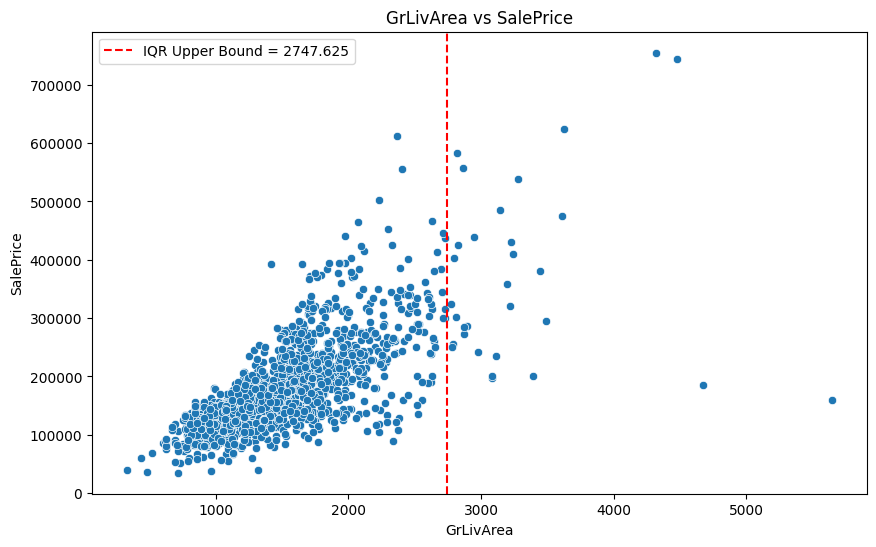

In [117]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_nonan,
    x="GrLivArea",
    y="SalePrice"
)

plt.axvline(
    2747.625,
    color="red",
    linestyle="--",
    label="IQR Upper Bound = 2747.625"
)

plt.legend()
plt.title("GrLivArea vs SalePrice")
plt.show()

`GrLivArea` dipilih karena menggambarkan luas area hunian utama dan memiliki hubungan yang relevan dengan `SalePrice`. Pada screening awal, ditemukan 4 observasi dengan `GrLivArea > 4000 sqft`. Setelah diperiksa berdasarkan luas area, kualitas rumah (`OverallQual`), dan harga jual, terdapat 2 anomali, yaitu Id 524 dan Id 1299, yang kemudian dihapus.

Selanjutnya, metode IQR diterapkan pada data setelah penghapusan tersebut. Hasilnya terdapat 29 observasi yang terdeteksi sebagai outlier secara statistik. Ke-29 observasi tetap dipertahankan karena outlier statistik belum tentu merupakan kesalahan data.



### Domain Knowledge: Categorical vs Numerical

In [118]:
# MSSubClass adalah kategorikal (tipe bangunan code)
print("=== Nilai Unik MSSubClass ===")
print(f"Banyaknya kategori: {df_clean['MSSubClass'].nunique()}")
print(f"Nilai-nilai: {sorted(df_clean['MSSubClass'].unique())}")
print()
print("Catatan: MSSubClass merepresentasikan tipe bangunan, bukan angka kontinu")
print("Contoh: 20 = 1-Story 1946 & Newer, 60 = 2-Story 1946 & Newer, dll")

=== Nilai Unik MSSubClass ===
Banyaknya kategori: 15
Nilai-nilai: [np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(120), np.int64(160), np.int64(180), np.int64(190)]

Catatan: MSSubClass merepresentasikan tipe bangunan, bukan angka kontinu
Contoh: 20 = 1-Story 1946 & Newer, 60 = 2-Story 1946 & Newer, dll


### MSSubClass Type Conversion

In [119]:
# Konversi MSSubClass dari integer ke string (kategorikal)
df_clean["MSSubClass"] = df_clean["MSSubClass"].astype(str)

print(f"Tipe data MSSubClass di Train: {df_clean['MSSubClass'].dtype}")

Tipe data MSSubClass di Train: object


## **5. PREPROCESSING & FEATURE ENGINEERING**

### Missing Values Imputation (Domain-Aware Strategy)

In [120]:
# ==============================
# PREPROCESSING: IMPUTASI MISSING VALUE
# ==============================

# Buat salinan dataset untuk preprocessing
df_prepos = df_clean.copy()

# Kolom kategorikal:
# NaN berarti fasilitas/fitur tersebut tidak tersedia
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "MasVnrType"
]

# Kolom numerik:
# NaN berarti fasilitas tersebut tidak tersedia, sehingga diisi 0
zero_cols = [
    "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath",
    "MasVnrArea"
]

# --------------------------------
# 1. Imputasi kolom kategorikal
# --------------------------------
for col in none_cols:
    if col in df_prepos.columns:
        df_prepos[col] = df_prepos[col].fillna("None")


# --------------------------------
# 2. Imputasi kolom numerik
# --------------------------------
for col in zero_cols:
    if col in df_prepos.columns:
        df_prepos[col] = df_prepos[col].fillna(0)


# --------------------------------
# 3. Imputasi LotFrontage
#    berdasarkan Neighborhood
# --------------------------------
if "LotFrontage" in df_prepos.columns:

    # Hitung median LotFrontage setiap Neighborhood
    neighborhood_median = (
        df_prepos.groupby("Neighborhood")["LotFrontage"]
        .transform("median")
    )

    # Isi missing berdasarkan median Neighborhood
    df_prepos["LotFrontage"] = (
        df_prepos["LotFrontage"]
        .fillna(neighborhood_median)
    )

    # Jika masih ada missing, gunakan median keseluruhan
    df_prepos["LotFrontage"] = (
        df_prepos["LotFrontage"]
        .fillna(df_prepos["LotFrontage"].median())
    )


# ==============================
# CEK HASIL IMPUTASI
# ==============================

missing_after = df_prepos.isnull().sum()
total_missing = missing_after.sum()

print("=== HASIL IMPUTASI MISSING VALUE ===")
print(f"Sisa total missing values : {total_missing}")
print(f"Shape dataset             : {df_prepos.shape}")

if total_missing == 0:
    print("✓ Tidak terdapat missing value setelah imputasi.")
else:
    print("\nKolom yang masih memiliki missing value:")
    print(missing_after[missing_after > 0])


=== HASIL IMPUTASI MISSING VALUE ===
Sisa total missing values : 82
Shape dataset             : (1458, 76)

Kolom yang masih memiliki missing value:
Electrical      1
GarageYrBlt    81
dtype: int64


Karena atribut Electrical adalah kategorik maka diisi dengan modus

In [121]:
df_prepos["Electrical"] = df_prepos["Electrical"].fillna(
    df_prepos["Electrical"].mode()[0]
)

GarageYrBlt berkaitan dengan tahun pembangunan garasi. Missing value sangat mungkin berarti rumah tidak memiliki garasi.

In [122]:
df_prepos.loc[
    df_prepos["GarageYrBlt"].isna(),
    ["Id", "GarageType", "GarageFinish", "GarageCars", "GarageArea", "GarageYrBlt"]
]


,Id,GarageType,GarageFinish,GarageCars,GarageArea,GarageYrBlt
39,40,None,None,0,0,NaN
48,49,None,None,0,0,NaN
78,79,None,None,0,0,NaN
88,89,None,None,0,0,NaN
89,90,None,None,0,0,NaN
99,100,None,None,0,0,NaN
108,109,None,None,0,0,NaN
125,126,None,None,0,0,NaN
127,128,None,None,0,0,NaN
140,141,None,None,0,0,NaN


Karena 81 GarageYrBlt yang missing memang berasal dari rumah yang tidak memiliki garasi, maka kita isi dengan nilai fillna(0)

In [123]:
df_prepos["GarageYrBlt"] = df_prepos["GarageYrBlt"].fillna(0)

Cek Seluruh atribut bahwa tidak ada missing value lagi

In [124]:
missing_after = df_prepos.isnull().sum()
total_missing = missing_after.sum()

print("=== HASIL IMPUTASI MISSING VALUE ===")
print(f"Sisa total missing values : {total_missing}")
print(f"Shape dataset             : {df_prepos.shape}")

if total_missing == 0:
    print("✓ Tidak terdapat missing value setelah imputasi.")
else:
    print("\nKolom yang masih memiliki missing value:")
    print(missing_after[missing_after > 0])

=== HASIL IMPUTASI MISSING VALUE ===
Sisa total missing values : 0
Shape dataset             : (1458, 76)
✓ Tidak terdapat missing value setelah imputasi.


Missing value ditangani berdasarkan makna dari masing-masing fitur. Fitur kategorikal yang menunjukkan tidak adanya fasilitas diisi dengan `"None"`, sedangkan fitur numerik yang menunjukkan tidak adanya fasilitas diisi dengan `0`. `LotFrontage` diimputasi menggunakan median berdasarkan `Neighborhood`.

Setelah imputasi awal, ditemukan 1 missing value pada `Electrical` dan 81 missing value pada `GarageYrBlt`. `Electrical` diisi menggunakan modus, sedangkan 81 nilai `GarageYrBlt` diisi dengan `0` karena seluruh observasi tersebut terbukti tidak memiliki garasi berdasarkan `GarageType`, `GarageFinish`, `GarageCars`, dan `GarageArea`.

Setelah imputasi selesai, tidak terdapat missing value yang tersisa pada dataset.

# **Normalisasi Data**

## **One-Hot Encoding**

Pemisahan Fitur & Target

In [125]:
X = df_prepos.drop(columns=["SalePrice"])
y = df_prepos["SalePrice"]

Identifikasi kolom kategorikal & Numerik

In [126]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(f"Jumlah fitur kategorikal : {len(categorical_cols)}")
print(f"Jumlah fitur numerik     : {len(numerical_cols)}")

Jumlah fitur kategorikal : 39
Jumlah fitur numerik     : 36


OneHot Encoding untuk fitur Kategorikal

In [127]:
encoder = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "numerical",
            "passthrough",
            numerical_cols
        )
    ]
)

X_encoded = encoder.fit_transform(X)
print(f"Shape sebelum One-Hot Encoding: {X.shape}")
print(f"\nShape setelah One-Hot Encoding: {X_encoded.shape}")

Shape sebelum One-Hot Encoding: (1458, 75)

Shape setelah One-Hot Encoding: (1458, 295)


Sebelum One-Hot Encoding, dataset memiliki 75 fitur yang terdiri dari 39 fitur kategorikal dan 36 fitur numerik. Setelah dilakukan One-Hot Encoding pada fitur kategorikal, jumlah fitur meningkat menjadi 295. Peningkatan jumlah fitur terjadi karena setiap kategori pada fitur kategorikal direpresentasikan sebagai kolom biner (0 dan 1), sedangkan fitur numerik tetap dipertahankan sebagai fitur numerik. Dengan demikian, One-Hot Encoding menghasilkan 220 fitur tambahan.

## **Standarisasi Fitur Numerik**

### Standardization & Scaling

In [128]:
# Standardisasi fitur

# Ambil nama fitur setelah One-Hot Encoding
feature_names = encoder.get_feature_names_out()

# Standardisasi
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_encoded),
    columns=feature_names,
    index=df_prepos.index
)

print("=== Hasil Standardisasi ===")
print(f"Dimensi X setelah scaling: {X_scaled.shape}")
print(f"Mean rata-rata: {X_scaled.mean().mean():.6f}")
print(f"Std rata-rata : {X_scaled.std().mean():.6f}")

=== Hasil Standardisasi ===
Dimensi X setelah scaling: (1458, 295)
Mean rata-rata: 0.000000
Std rata-rata : 1.000343


In [129]:
df_prepos_norm = X_scaled.copy()

print("\nShape df_prepos_norm:", df_prepos_norm.shape)
display(df_prepos_norm.head())


Shape df_prepos_norm: (1458, 295)


,categorical__MSSubClass_120,categorical__MSSubClass_160,categorical__MSSubClass_180,categorical__MSSubClass_190,categorical__MSSubClass_20,categorical__MSSubClass_30,categorical__MSSubClass_40,categorical__MSSubClass_45,categorical__MSSubClass_50,categorical__MSSubClass_60,categorical__MSSubClass_70,categorical__MSSubClass_75,categorical__MSSubClass_80,categorical__MSSubClass_85,categorical__MSSubClass_90,categorical__MSZoning_C (all),categorical__MSZoning_FV,categorical__MSZoning_RH,categorical__MSZoning_RL,categorical__MSZoning_RM,categorical__Street_Grvl,categorical__Street_Pave,categorical__LotShape_IR1,categorical__LotShape_IR2,categorical__LotShape_IR3,categorical__LotShape_Reg,categorical__LandContour_Bnk,categorical__LandContour_HLS,categorical__LandContour_Low,categorical__LandContour_Lvl,categorical__Utilities_AllPub,categorical__Utilities_NoSeWa,categorical__LotConfig_Corner,categorical__LotConfig_CulDSac,categorical__LotConfig_FR2,categorical__LotConfig_FR3,categorical__LotConfig_Inside,categorical__LandSlope_Gtl,categorical__LandSlope_Mod,categorical__LandSlope_Sev,categorical__Neighborhood_Blmngtn,categorical__Neighborhood_Blueste,categorical__Neighborhood_BrDale,categorical__Neighborhood_BrkSide,categorical__Neighborhood_ClearCr,categorical__Neighborhood_CollgCr,categorical__Neighborhood_Crawfor,categorical__Neighborhood_Edwards,categorical__Neighborhood_Gilbert,categorical__Neighborhood_IDOTRR,categorical__Neighborhood_MeadowV,categorical__Neighborhood_Mitchel,categorical__Neighborhood_NAmes,categorical__Neighborhood_NPkVill,categorical__Neighborhood_NWAmes,categorical__Neighborhood_NoRidge,categorical__Neighborhood_NridgHt,categorical__Neighborhood_OldTown,categorical__Neighborhood_SWISU,categorical__Neighborhood_Sawyer,categorical__Neighborhood_SawyerW,categorical__Neighborhood_Somerst,categorical__Neighborhood_StoneBr,categorical__Neighborhood_Timber,categorical__Neighborhood_Veenker,categorical__Condition1_Artery,categorical__Condition1_Feedr,categorical__Condition1_Norm,categorical__Condition1_PosA,categorical__Condition1_PosN,categorical__Condition1_RRAe,categorical__Condition1_RRAn,categorical__Condition1_RRNe,categorical__Condition1_RRNn,categorical__Condition2_Artery,categorical__Condition2_Feedr,categorical__Condition2_Norm,categorical__Condition2_PosA,categorical__Condition2_PosN,categorical__Condition2_RRAe,categorical__Condition2_RRAn,categorical__Condition2_RRNn,categorical__BldgType_1Fam,categorical__BldgType_2fmCon,categorical__BldgType_Duplex,categorical__BldgType_Twnhs,categorical__BldgType_TwnhsE,categorical__HouseStyle_1.5Fin,categorical__HouseStyle_1.5Unf,categorical__HouseStyle_1Story,categorical__HouseStyle_2.5Fin,categorical__HouseStyle_2.5Unf,categorical__HouseStyle_2Story,categorical__HouseStyle_SFoyer,categorical__HouseStyle_SLvl,categorical__RoofStyle_Flat,categorical__RoofStyle_Gable,categorical__RoofStyle_Gambrel,categorical__RoofStyle_Hip,categorical__RoofStyle_Mansard,categorical__RoofStyle_Shed,categorical__RoofMatl_CompShg,categorical__RoofMatl_Membran,categorical__RoofMatl_Metal,categorical__RoofMatl_Roll,categorical__RoofMatl_Tar&Grv,categorical__RoofMatl_WdShake,categorical__RoofMatl_WdShngl,categorical__Exterior1st_AsbShng,categorical__Exterior1st_AsphShn,categorical__Exterior1st_BrkComm,categorical__Exterior1st_BrkFace,categorical__Exterior1st_CBlock,categorical__Exterior1st_CemntBd,categorical__Exterior1st_HdBoard,categorical__Exterior1st_ImStucc,categorical__Exterior1st_MetalSd,categorical__Exterior1st_Plywood,categorical__Exterior1st_Stone,categorical__Exterior1st_Stucco,categorical__Exterior1st_VinylSd,categorical__Exterior1st_Wd Sdng,categorical__Exterior1st_WdShing,categorical__Exterior2nd_AsbShng,categorical__Exterior2nd_AsphShn,categorical__Exterior2nd_Brk Cmn,categorical__Exterior2nd_BrkFace,categorical__Exterior2nd_CBlock,categorical__Exterior2nd_CmentBd,categorical__Exterior2nd_HdBoard,categorical__Exterior2nd_ImStucc,categorical__Exterior2nd_MetalSd,categorica

Setelah One-Hot Encoding, jumlah fitur menjadi 295 dan seluruh fitur telah berbentuk numerik. Selanjutnya dilakukan standardisasi menggunakan `StandardScaler` agar seluruh fitur berada pada skala yang sebanding. Hasil standardisasi memiliki mean yang mendekati 0 dan standar deviasi yang mendekati 1. Data hasil standardisasi disimpan dalam `df_prepos_norm` dan selanjutnya digunakan untuk analisis multikolinearitas dan PCA.


## **Multikolinearitas Analysis**

Pemeriksaan Nilai VIF

In [130]:
# Ambil fitur numerik asli sebelum One-Hot Encoding
X_vif = df_prepos.select_dtypes(
    include=["int64", "float64"]
).drop(columns=["SalePrice"], errors="ignore").copy()

# Hitung VIF
vif_df = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Urutkan dari VIF terbesar
vif_df = (
    vif_df
    .sort_values(by="VIF", ascending=False)
    .reset_index(drop=True)
)

print("=== HASIL PEMERIKSAAN MULTIKOLINEARITAS ===")
display(vif_df)

=== HASIL PEMERIKSAAN MULTIKOLINEARITAS ===


,Feature,VIF
0,BsmtFinSF1,1.000800e+15
1,BsmtFinSF2,1.000800e+15
2,BsmtUnfSF,1.000800e+15
3,TotalBsmtSF,1.000800e+15
4,GrLivArea,1.000800e+15
5,LowQualFinSF,1.000800e+15
6,2ndFlrSF,1.000800e+15
7,1stFlrSF,1.000800e+15
8,GarageCars,6.224716e+00
9,GarageArea,5.295112e+00


Berdasarkan hasil pemeriksaan menggunakan Variance Inflation Factor (VIF), ditemukan beberapa fitur dengan nilai VIF yang sangat tinggi, terutama `BsmtFinSF1`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF`, `GrLivArea`, `LowQualFinSF`, `2ndFlrSF`, dan `1stFlrSF`. Nilai VIF yang sangat tinggi menunjukkan adanya hubungan linear yang sangat kuat antarfitur. Kondisi ini dapat dijelaskan secara struktural karena beberapa fitur merupakan bagian atau kombinasi dari fitur lainnya, seperti `TotalBsmtSF` yang berkaitan dengan luas basement yang telah selesai dan belum selesai, serta `GrLivArea` yang berkaitan dengan luas lantai pertama, lantai kedua, dan area dengan kualitas rendah.

Fitur dengan VIF tinggi tidak langsung dihapus karena tahap selanjutnya menggunakan PCA untuk melakukan reduksi dimensi dan mengurangi redundansi informasi antarfitur.


### **Analisis Korelasi Matrix >=0.7**

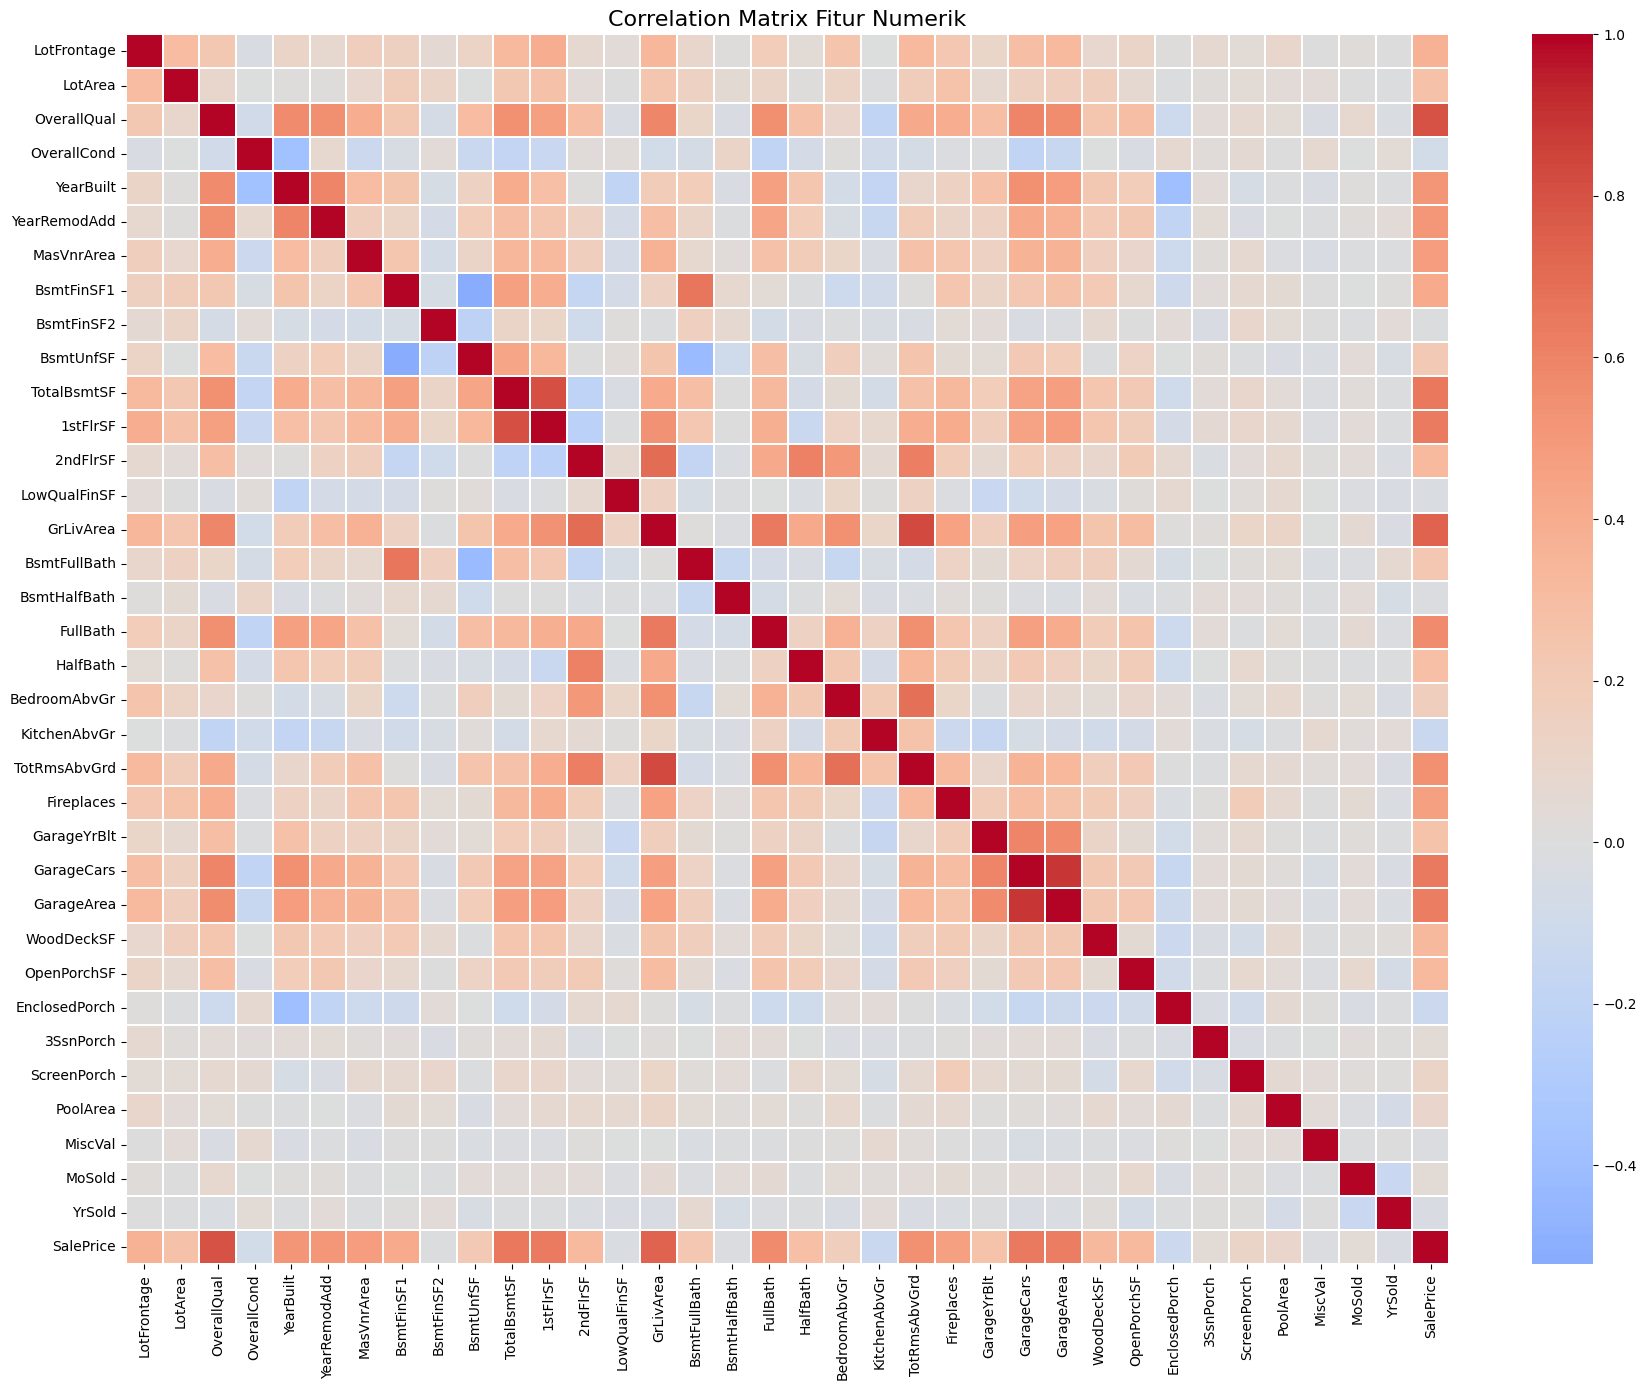

=== PASANGAN FITUR DENGAN KORELASI TINGGI (|r| >= 0.7) ===
Jumlah pasangan: 5


,Feature_1,Feature_2,Correlation
0,GarageCars,GarageArea,0.887304
1,GrLivArea,TotRmsAbvGrd,0.829498
2,TotalBsmtSF,1stFlrSF,0.803830
3,OverallQual,SalePrice,0.795774
4,GrLivArea,SalePrice,0.734968


In [131]:
# Ambil fitur numerik dan keluarkan Id
corr_data = df_prepos.select_dtypes(
    include=["int64", "float64"]
).drop(columns=["Id"], errors="ignore")

# Hitung correlation matrix
corr_matrix = corr_data.corr()

# Visualisasi correlation matrix
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Matrix Fitur Numerik", fontsize=16)
plt.tight_layout()
plt.show()

# Ambil pasangan fitur yang memiliki korelasi tinggi
corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

# Filter korelasi tinggi
high_corr = (
    corr_pairs[
        corr_pairs["Correlation"].abs() >= 0.7
    ]
    .sort_values(
        by="Correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)

print("=== PASANGAN FITUR DENGAN KORELASI TINGGI (|r| >= 0.7) ===")
print(f"Jumlah pasangan: {len(high_corr)}")
display(high_corr)


Berdasarkan correlation matrix, terdapat beberapa pasangan fitur dengan korelasi tinggi (|r| ≥ 0.7). Korelasi tertinggi ditemukan antara `GarageCars` dan `GarageArea` sebesar 0.8873, yang menunjukkan hubungan linear positif yang kuat. Selanjutnya, `GrLivArea` dan `TotRmsAbvGrd` memiliki korelasi sebesar 0.8295, sedangkan `TotalBsmtSF` dan `1stFlrSF` memiliki korelasi sebesar 0.8038.

Selain hubungan antarfitur, terdapat korelasi antara fitur dengan target `SalePrice`, yaitu `OverallQual` sebesar 0.7958 dan `GrLivArea` sebesar 0.7350. Korelasi dengan `SalePrice` digunakan untuk memahami hubungan fitur dengan target dan tidak dikategorikan sebagai multikolinearitas antarfitur prediktor.


# CEK NAN

In [132]:
# Cek missing value sebelum PCA
nan_check = df_prepos_norm.isnull().sum()

nan_check = nan_check[nan_check > 0].sort_values(ascending=False)

print("=== CEK MISSING VALUE SEBELUM PCA ===")

if len(nan_check) == 0:
    print("Tidak terdapat missing value.")
else:
    print("Kolom yang masih memiliki missing value:")
    print(nan_check)



=== CEK MISSING VALUE SEBELUM PCA ===
Tidak terdapat missing value.


### PCA Dimensionality Reduction

In [133]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(df_prepos_norm)

# Cumulative explained variance
cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

# Cari jumlah komponen yang mempertahankan >= 90% variance
n_components_90 = (
    np.argmax(cumulative_variance >= 0.90) + 1
)

print("\n=== HASIL PCA ===")
print(
    f"Jumlah fitur sebelum PCA      : "
    f"{df_prepos_norm.shape[1]}"
)

print(
    f"Jumlah komponen untuk 90% variance : "
    f"{n_components_90}"
)

print(
    f"Variance yang dipertahankan   : "
    f"{cumulative_variance[n_components_90 - 1]:.4f}"
)

print(
    f"Pengurangan dimensi           : "
    f"{df_prepos_norm.shape[1]} → {n_components_90}"
)


=== HASIL PCA ===
Jumlah fitur sebelum PCA      : 295
Jumlah komponen untuk 90% variance : 148
Variance yang dipertahankan   : 0.9016
Pengurangan dimensi           : 295 → 148


Visualisasi PCA

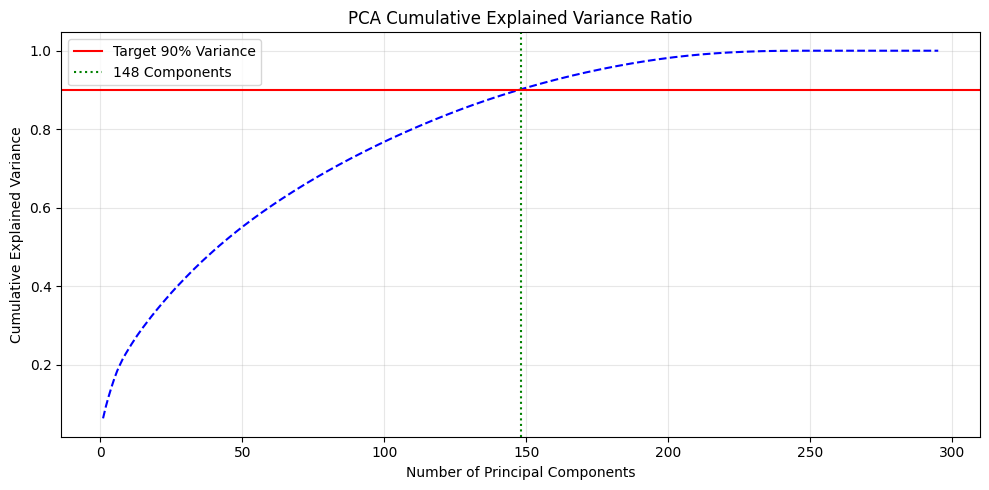

In [134]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    linestyle="--",
    color="blue"
)

plt.axhline(
    y=0.90,
    color="red",
    linestyle="-",
    label="Target 90% Variance"
)

plt.axvline(
    x=n_components_90,
    color="green",
    linestyle=":",
    label=f"{n_components_90} Components"
)

plt.title("PCA Cumulative Explained Variance Ratio")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### PCA 2D Visualization

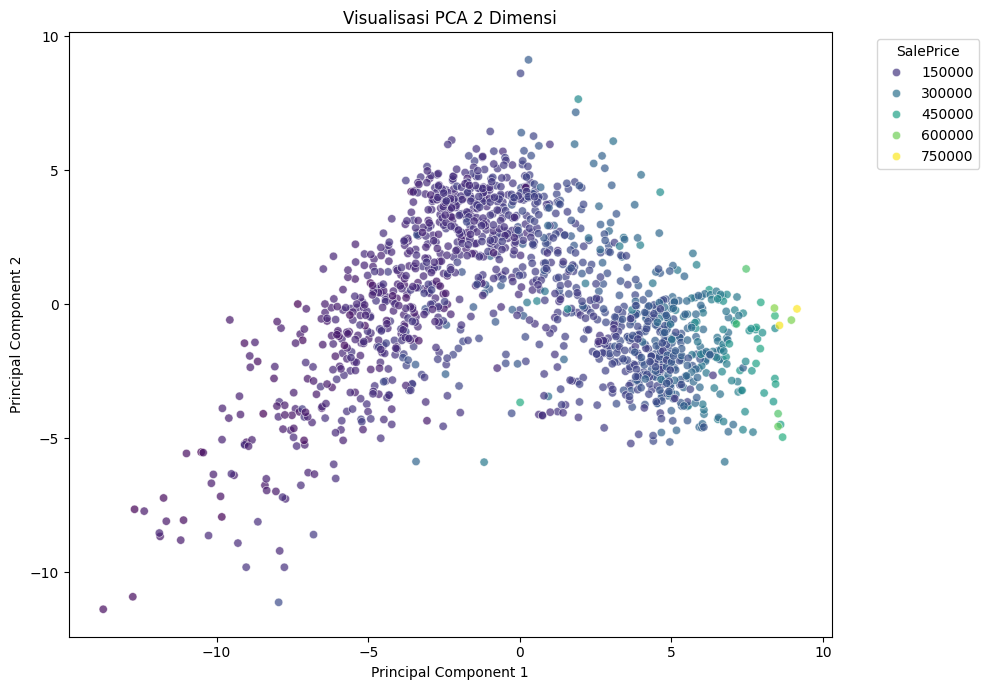

=== PCA 2 DIMENSI ===
PC1 menjelaskan variance: 0.0638
PC2 menjelaskan variance: 0.0302
Total variance PC1 + PC2: 0.0940


In [135]:
# PCA 2 komponen khusus untuk visualisasi
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(df_prepos_norm)

# Buat DataFrame
df_pca_2d = pd.DataFrame(
    X_pca_2d,
    columns=["PC1", "PC2"],
    index=df_prepos_norm.index
)

# Tambahkan SalePrice untuk visualisasi
df_pca_2d["SalePrice"] = df_prepos.loc[
    df_prepos_norm.index, "SalePrice"
]

# Visualisasi
plt.figure(figsize=(10, 7))

scatter = sns.scatterplot(
    data=df_pca_2d,
    x="PC1",
    y="PC2",
    hue="SalePrice",
    palette="viridis",
    alpha=0.7
)

plt.title("Visualisasi PCA 2 Dimensi")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(
    title="SalePrice",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Explained variance PCA 2D
print("=== PCA 2 DIMENSI ===")
print(
    f"PC1 menjelaskan variance: "
    f"{pca_2d.explained_variance_ratio_[0]:.4f}"
)
print(
    f"PC2 menjelaskan variance: "
    f"{pca_2d.explained_variance_ratio_[1]:.4f}"
)
print(
    f"Total variance PC1 + PC2: "
    f"{pca_2d.explained_variance_ratio_.sum():.4f}"
)

PCA Final

In [136]:
pca_optimal = PCA(
    n_components=n_components_90
)

X_pca = pca_optimal.fit_transform(
    df_prepos_norm
)

Ubah ke Dataframe

In [137]:
pc_columns = [
    f"PC{i+1}"
    for i in range(X_pca.shape[1])
]

df_pca = pd.DataFrame(
    X_pca,
    columns=pc_columns,
    index=df_prepos_norm.index
)

Hasil akhir

In [138]:
print("\n=== HASIL REDUKSI DIMENSI PCA ===")
print(
    f"Shape sebelum PCA : "
    f"{df_prepos_norm.shape}"
)

print(
    f"Shape setelah PCA : "
    f"{df_pca.shape}"
)

print(
    f"Total variance yang dipertahankan : "
    f"{pca_optimal.explained_variance_ratio_.sum():.4f}"
)

display(df_pca.head())


=== HASIL REDUKSI DIMENSI PCA ===
Shape sebelum PCA : (1458, 295)
Shape setelah PCA : (1458, 148)
Total variance yang dipertahankan : 0.8998


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50,PC51,PC52,PC53,PC54,PC55,PC56,PC57,PC58,PC59,PC60,PC61,PC62,PC63,PC64,PC65,PC66,PC67,PC68,PC69,PC70,PC71,PC72,PC73,PC74,PC75,PC76,PC77,PC78,PC79,PC80,PC81,PC82,PC83,PC84,PC85,PC86,PC87,PC88,PC89,PC90,PC91,PC92,PC93,PC94,PC95,PC96,PC97,PC98,PC99,PC100,PC101,PC102,PC103,PC104,PC105,PC106,PC107,PC108,PC109,PC110,PC111,PC112,PC113,PC114,PC115,PC116,PC117,PC118,PC119,PC120,PC121,PC122,PC123,PC124,PC125,PC126,PC127,PC128,PC129,PC130,PC131,PC132,PC133,PC134,PC135,PC136,PC137,PC138,PC139,PC140,PC141,PC142,PC143,PC144,PC145,PC146,PC147,PC148
0,4.032587,-2.160814,-0.403655,-1.250583,-1.986485,-2.110187,0.897920,-1.826266,0.447690,1.265163,-0.308613,0.013471,-0.177261,0.449555,-0.784301,1.733923,-0.945521,-1.517943,-0.853185,-0.283728,0.288547,0.360403,-0.007712,0.287854,-0.267300,1.383118,-0.425405,0.263577,-0.505659,0.685351,-0.330317,-0.556025,0.948489,-0.882450,-0.446486,-0.317150,-0.522826,0.472408,-0.004294,-0.787979,-0.266873,-0.161275,0.271697,0.071232,0.115130,-0.134773,0.096231,1.278086,0.696255,0.144921,0.368938,-0.137220,0.120620,-0.159216,-1.049641,0.301165,0.276556,0.387089,-0.121278,-0.286504,-0.290148,-0.486366,0.204329,-1.200963,0.309300,0.101453,0.925260,-0.414623,0.269844,-0.150389,-0.014489,0.153643,0.141398,-0.224568,-0.137932,-0.300202,0.287143,-0.549755,-0.361284,-0.686394,0.243462,-0.066965,0.101272,-0.161312,-0.250954,0.221622,-0.045917,-0.151403,-0.251214,-0.587011,-0.039990,-0.551749,-0.030056,-0.016093,-0.068040,-0.541970,0.600628,-0.349402,0.056110,0.054236,-0.444506,-0.575526,-0.226365,0.331357,0.324983,0.167904,-0.312414,-0.214972,-0.933793,0.179935,0.045463,-0.575845,-0.127266,-0.515504,-0.296844,0.679517,-0.317604,0.198077,0.093140,-0.556178,0.023951,-0.461677,-0.827232,-0.068673,-0.097527,0.108691,0.059316,0.070009,-0.336088,-0.603720,0.186434,-0.180990,0.087207,0.295994,-0.142766,-0.078168,-0.016690,-0.425571,0.267193,-0.453350,0.199478,0.035826,-0.054362,-0.217985,-0.161467,0.025713,0.474982,0.339628
1,0.509934,3.494512,0.150568,-0.493917,0.828998,-0.651529,0.148702,-0.224378,-0.136016,1.467330,-0.694847,-1.583103,0.142445,1.130045,1.528836,-1.086881,-0.675717,-0.286780,2.519315,-1.129376,0.690656,-0.436366,-0.390514,-1.232140,0.446486,-1.281033,0.582259,-0.211421,-0.456643,0.098622,-0.728630,0.382625,-2.043993,0.228481,2.332593,-2.572410,0.384455,-0.072482,0.181117,0.961449,-2.573000,-0.506757,1.167486,1.053978,2.057396,-0.780916,1.293028,-0.878973,-0.966878,0.159114,0.899327,-0.580527,-1.343238,0.104750,0.260423,0.491321,-0.716229,2.392112,-0.913979,-1.564229,3.401225,-0.991040,-0.711643,-0.526196,-2.582663,0.884354,2.277044,-0.151444,-1.210940,-2.361013,-0.829940,-1.213817,-2.119911,1.533177,0.342985,0.937997,3.480268,-1.428952,0.315292,-3.311833,0.028897,-0.407601,-2.420928,0.511145,0.086504,-2.178362,0.651781,-0.260995,-1.509542,2.727743,1.071973,-2.109398,-1.160475,-0.322174,0.737526,0.549912,1.479497,-0.127838,0.104789,0.198711,1.062237,0.099183,1.628764,-0.932471,-1.690231,-0.330819,-0.276551,-0.164943,0.222840,-0.344566,1.789446,1.409906,-0.516951,-0.647267,1.348844,-0.768371,-2.000444,2.028751,-0.797645,-0.754696,-1.161302,1.062431,-2.364907,1.542133,-1.066576,0.640198,0.737787,-0.499313,0.312351,1.067947,-0.845046,2.418222,-1.118338,-1.086022,1.084141,1.118416,-0.012364,-1.008974,-1.801200,-0.001659,2.774724,-0.060939,1.568868,-0.252990,-0.427222,-0.214734,-0.670502,0.664143
2,4.907536,-1.663544,-0.149530,-0.183712,-1.412474,-2.526920,0.727960,-2.491868,0.120988,1.638167,-0.112591,0.090030,0.026619,0.294863,-0.541832,0.455290,-0.249811,-0.825123,0.101265,-0.082575,0.457233,0.370398,0.536344,-0.054915,0.131316,0.921969,-0.194197,0.210006,-1.047200,0.252502,-0.609913,-0.370822,0.108881,-0.057475,-0.324494,0.590228,-0.088665,0.459467,0.029637,-1.034440,-0.0

Selain PCA utama yang menghasilkan 148 komponen untuk mempertahankan sekitar 90% variance, dilakukan PCA dengan 2 komponen khusus untuk visualisasi. PC1 dan PC2 digunakan sebagai sumbu pada scatter plot untuk melihat distribusi data dalam ruang berdimensi rendah. Warna titik menunjukkan nilai `SalePrice` sebagai target, tetapi `SalePrice` tidak digunakan dalam proses pembentukan komponen PCA. Visualisasi ini digunakan untuk mengamati pola atau persebaran data secara eksploratif dan bukan sebagai pengganti PCA utama yang menghasilkan 148 komponen.


## **6. EXPORT DATA**

In [140]:
# Gabungkan hasil PCA dengan target SalePrice
df_pca_final = df_pca.copy()

df_pca_final["SalePrice"] = df_prepos.loc[
    df_pca.index, "SalePrice"
]

# Ekspor ke CSV
df_pca_final.to_csv(
    "train_final.csv",
    index=False
)

print("File berhasil diekspor: train_final.csv")
print(f"Shape data: {df_pca_final.shape}")


File berhasil diekspor: train_final.csv
Shape data: (1458, 149)


## **PREPROCESSING SUMMARY**

Berdasarkan seluruh proses EDA dan preprocessing pada `train.csv`, dapat disimpulkan bahwa:

- EDA dilakukan untuk memahami struktur, karakteristik, distribusi, kualitas data, missing value, skewness, serta hubungan antarfitur dan `SalePrice`.
- Missing value ditangani berdasarkan makna masing-masing fitur, termasuk penggunaan `"None"`, nilai 0, dan imputasi median berdasarkan `Neighborhood`.
- `MSSubClass` dikonversi dari integer menjadi string karena merupakan fitur kategorikal.
- Deteksi outlier dilakukan menggunakan pemeriksaan `GrLivArea > 4000 sqft` dan metode IQR. Dari empat observasi dengan luas di atas 4.000 sqft, dua observasi yang dianggap sebagai anomali ekstrem dihapus. Sebanyak 29 observasi teridentifikasi oleh metode IQR, tetapi tidak seluruhnya dihapus karena dapat merepresentasikan variasi data yang valid.
- Analisis skewness digunakan untuk mengetahui karakteristik distribusi fitur numerik.
- One-Hot Encoding mengubah fitur kategorikal menjadi representasi numerik dan meningkatkan jumlah fitur dari **75 menjadi 295**.
- Standardisasi dilakukan agar fitur berada pada skala yang sebanding.
- Correlation matrix menunjukkan adanya beberapa hubungan linear yang kuat antarfitur, terutama `GarageCars`–`GarageArea`, `GrLivArea`–`TotRmsAbvGrd`, dan `TotalBsmtSF`–`1stFlrSF`.
- Pemeriksaan VIF menunjukkan adanya multikolinearitas pada beberapa fitur yang memiliki hubungan struktural.
- PCA digunakan untuk mengurangi dimensi data dari **295 menjadi 148 komponen**, dengan **90,16% variance** tetap dipertahankan.
- PCA 2 dimensi digunakan untuk visualisasi, sedangkan 148 komponen digunakan sebagai hasil reduksi dimensi utama.
